## Importing Libraries

In [39]:
# Core data manipulation library
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns            # Advanced statistical visualizations

# Interactive widgets for Jupyter notebooks
from ipywidgets import Dropdown, IntSlider, interact

# Machine learning utilities
from sklearn.model_selection import train_test_split  # Split data into training and test sets
from category_encoders import OneHotEncoder            # Convert categorical variables into numeric form
from sklearn.linear_model import Ridge  # Ridge regression (linear model with L2 regularization)
from sklearn.metrics import mean_absolute_error       # Evaluate regression model performance
from sklearn.pipeline import make_pipeline            # Build ML pipelines for preprocessing + modeling

## Housing Data Wrangling
Loads and cleans housing listings, returning a filtered and prepared dataset for analysis.

In [40]:
def wrangle(filepath):
    # Load data
    df = pd.read_csv(filepath)
    
    # Keep only listings in Abuja
    df = df[df['state'] == 'Abuja']
    
    # Ensure numeric columns are integers
    df['bedrooms'] = df['bedrooms'].astype(int)
    df['bathrooms'] = df['bathrooms'].astype(int)
    df['toilets'] = df['toilets'].astype(int)
    
    # Convert price to USD
    df['price_usd'] = df['price'] / 377  # In 2020: 1 USD = 377 NGN
    
    # Remove extreme price outliers (keep listings within 90th percentile)
    upper = df['price_usd'].quantile(0.90)
    df = df[df['price_usd'] <= upper]
    
    # Drop columns that are no longer needed
    df.drop(columns=['price', 'parking_space', 'state'], inplace=True)
    
    return df

In [41]:
df = wrangle('../data/nigeria_houses_data.csv')
print(df.shape)
df.head()

(3178, 6)


,bedrooms,bathrooms,toilets,title,town,price_usd
0,6,5,5,Detached Duplex,Mabushi,1.193634e+06
10,3,4,5,Terraced Duplexes,Lokogoma District,6.631300e+04
17,3,3,4,Detached Bungalow,Lokogoma District,9.814324e+04
23,5,6,7,Detached Duplex,Katampe,4.244032e+05
34,5,5,6,Detached Duplex,Kaura,3.978780e+05


## Bedrooms Distribution
Visualizes the distribution of bedroom counts in the cleaned housing dataset with a labeled histogram.

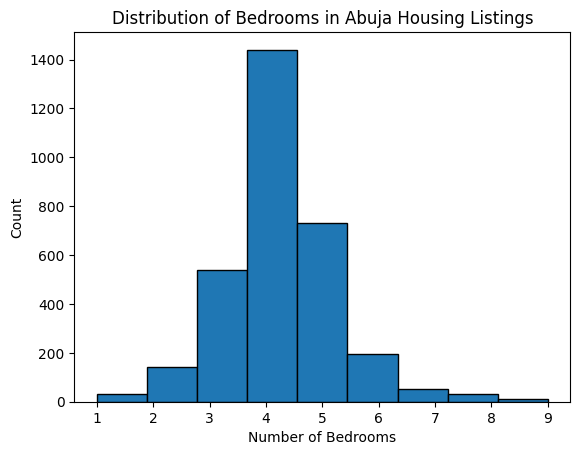

In [42]:
# Plot a histogram of the 'bedrooms' column with labels and title
plt.hist(df['bedrooms'], bins=9, edgecolor='black')

# Add title and axis labels
plt.title('Distribution of Bedrooms in Abuja Housing Listings')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')

# Display the plot
plt.show()

# Close the plot to free memory
plt.close()

Most housing listings are concentrated around 3–5 bedrooms, with 4-bedroom properties being the most common.

## Price Distribution
Plots a histogram showing the distribution of housing prices in USD for Abuja listings.

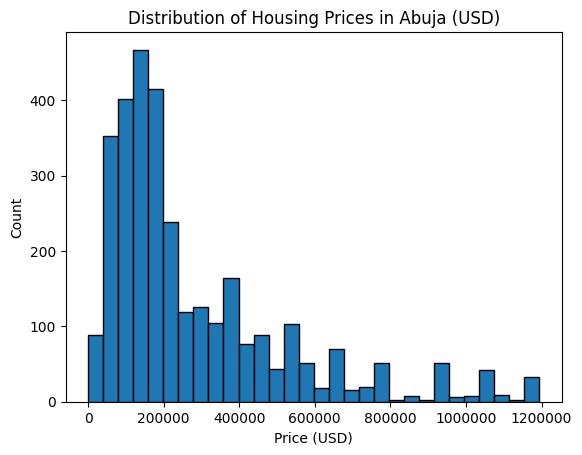

In [43]:
# Plot a histogram of the 'price_usd' column
plt.hist(df['price_usd'], bins=30, edgecolor='black')

# Add title and axis labels
plt.title('Distribution of Housing Prices in Abuja (USD)')
plt.xlabel('Price (USD)')
plt.ylabel('Count')

# Remove scientific notation on the x-axis
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')

# Display the plot
plt.show()

# Close the plot to free memory
plt.close()

Most properties are priced between about $100k–$300k, with a long tail of higher-priced listings extending beyond $1M.


## Price Boxplot
Displays a horizontal boxplot of housing prices in USD for Abuja listings, highlighting outliers.

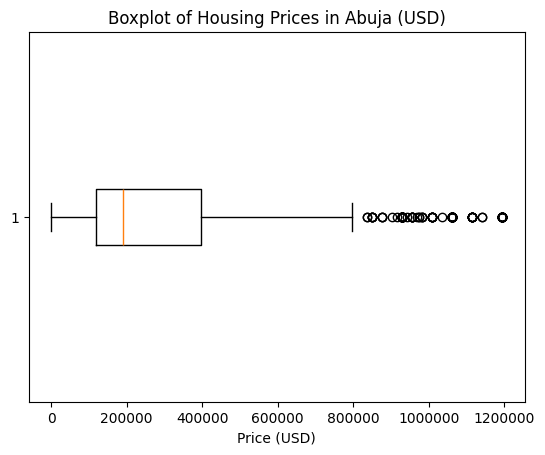

In [44]:
# Create a horizontal boxplot for 'price_usd'
plt.boxplot(df['price_usd'], vert=False)

# Add title and axis label
plt.title('Boxplot of Housing Prices in Abuja (USD)')
plt.xlabel('Price (USD)')

# Remove scientific notation on the x-axis
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')

# Display the plot
plt.show()

# Close the plot to free memory
plt.close()

Housing prices in Abuja are highly right-skewed, with most properties clustered at lower prices and a significant number of expensive outliers driving the upper range.

## Price vs Bedrooms
Scatter plot to visualize the relationship between housing prices in USD and the number of bedrooms.

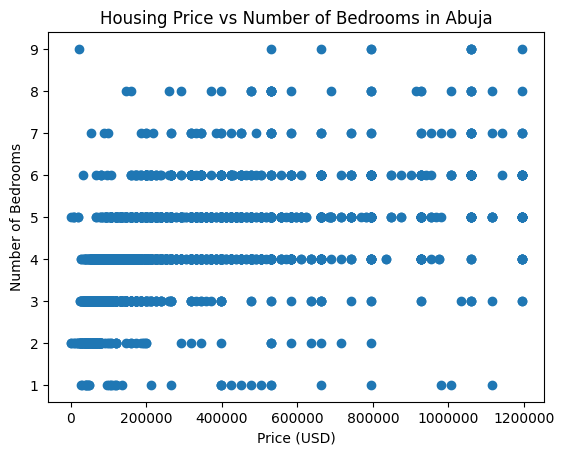

In [45]:
# Scatter plot of price vs number of bedrooms
plt.scatter(data=df, x='price_usd', y='bedrooms')

# Add title and axis labels
plt.title('Housing Price vs Number of Bedrooms in Abuja')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Bedrooms')

# Remove scientific notation on the x-axis
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')

# Display the plot
plt.show()

# Close the plot to free memory
plt.close()

Housing prices generally increase with the number of bedrooms, but there is significant overlap, indicating other factors also strongly influence price.


## Price Correlations
Calculates the Pearson correlation between housing prices in USD and numeric features: bedrooms, bathrooms, and toilets.

In [46]:
# Compute correlations of price with bedrooms, bathrooms, and toilets
corr_bed = df['price_usd'].corr(df['bedrooms'])
corr_bath = df['price_usd'].corr(df['bathrooms'])
corr_toilets = df['price_usd'].corr(df['toilets'])

# Print the correlation values with clear labels
print(f"Correlation between Price and Bedrooms: {corr_bed:.2f}")
print(f"Correlation between Price and Bathrooms: {corr_bath:.2f}")
print(f"Correlation between Price and Toilets: {corr_toilets:.2f}")

Correlation between Price and Bedrooms: 0.50
Correlation between Price and Bathrooms: 0.38
Correlation between Price and Toilets: 0.35


# Prepare Features and Target
Splits the dataset.

In [47]:
# Define features (X) and target (y)
X = df.drop(columns=["price_usd"])   # All columns except the target
y = df["price_usd"]                  # Target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% of data for testing
    random_state=42   # Ensures reproducible splits
)

# Optional: print shapes to verify
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (2542, 5), X_test: (636, 5)
y_train: (2542,), y_test: (636,)


# Baseline Model
Calculates a simple baseline using the mean of the training target and evaluates it with mean absolute error (MAE).

In [48]:
# Calculate the mean of the training target (baseline prediction)
y_mean = y_train.mean()

# Create baseline predictions by assigning the mean price to all training examples
y_pred_baseline = [y_mean] * len(y_train)

# Print the mean price
print(f"Mean Price (Baseline Prediction): {y_mean:.2f} USD")

# Evaluate the baseline using Mean Absolute Error (MAE)
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)
print(f"Baseline Mean Absolute Error: {baseline_mae:.2f} USD")

Mean Price (Baseline Prediction): 285744.28 USD
Baseline Mean Absolute Error: 187799.72 USD


## Ridge Regression Pipeline
Creates and fits a machine learning pipeline with one-hot encoding for categorical features and Ridge regression for predicting housing prices.

In [49]:
# Create a pipeline: one-hot encode categorical variables, then apply Ridge regression
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),  # Convert categorical features to numeric
    Ridge()                             # Ridge regression model
)

# Fit the model on the training data
model.fit(X_train, y_train)

# Optional: print confirmation
print("Ridge regression pipeline successfully trained.")

Ridge regression pipeline successfully trained.


## Model Evaluation
Predicts housing prices on the training set and compares the Ridge model performance against the baseline using Mean Absolute Error (MAE).

In [50]:
# Predict prices on the training set using the trained Ridge regression model
y_pred = model.predict(X_train)

# Evaluate and print the baseline MAE
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)
print(f"Baseline Mean Absolute Error: {baseline_mae:.2f} USD")

# Evaluate and print the Ridge model MAE on training data
training_mae = mean_absolute_error(y_train, y_pred)
print(f"Ridge Model Training MAE: {training_mae:.2f} USD")

Baseline Mean Absolute Error: 187799.72 USD
Ridge Model Training MAE: 111253.67 USD


## Test Set Evaluation
Evaluates the Ridge regression model on unseen test data using Mean Absolute Error (MAE).

In [51]:
# Predict housing prices on the test set
y_pred_test = model.predict(X_test)

# Calculate and print the MAE on test data
test_mae = mean_absolute_error(y_test, y_pred_test)
print(f"Ridge Model Test MAE: {test_mae:.2f} USD")

Ridge Model Test MAE: 120702.21 USD


# Predict Apartment Price
Predicts the price of a single apartment given its features using the trained Ridge regression model.

In [52]:
def make_prediction(bedrooms, bathrooms, toilets, title, town):
    # Create a dataframe with a single row containing the apartment features
    data = {
        'bedrooms': bedrooms, 
        'bathrooms': bathrooms, 
        'toilets': toilets,
        'title': title,
        'town': town
    }
    df_single = pd.DataFrame(data, index=[0])
    
    # Predict the price using the trained Ridge regression model
    prediction = model.predict(df_single)
    
    # Return formatted prediction
    return f"Predicted apartment price: ${round(prediction[0], 2)}"

## Example Prediction
Demonstrates using the `make_prediction` function to estimate the price of a single apartment in Abuja.

In [53]:
# Predict the price of an apartment with the following features:
# - 2 bedrooms
# - 1 bathroom
# - 1 toilet
# - Property type: "Block of Flats"
# - Town/Neighborhood: "Life Camp"
prediction_result = make_prediction(2, 1, 1, "Block of Flats", "Life Camp")

# Display the prediction
print(prediction_result)

Predicted apartment price: $126218.88


## Interactive Price Prediction
Provides sliders and dropdowns to interactively predict apartment prices using the trained Ridge regression model.

In [54]:
# Create interactive widgets for predicting apartment price
interact(
    make_prediction,
    
    # Slider for number of bedrooms
    bedrooms=IntSlider(
        min=X_train["bedrooms"].min(),                 # Minimum bedrooms in training set
        max=X_train["bedrooms"].max(),                 # Maximum bedrooms in training set
        value=int(X_train["bedrooms"].mean()),         # Default to average bedrooms
        description='Bedrooms'
    ),
    
    # Slider for number of bathrooms
    bathrooms=IntSlider(
        min=X_train["bathrooms"].min(),
        max=X_train["bathrooms"].max(),
        value=int(X_train["bathrooms"].mean()),
        description='Bathrooms'
    ),
    
    # Slider for number of toilets
    toilets=IntSlider(
        min=X_train["toilets"].min(),
        max=X_train["toilets"].max(),
        value=int(X_train["toilets"].mean()),
        description='Toilets'
    ),
    
    # Dropdown for property type/title
    title=Dropdown(
        options=sorted(X_train["title"].unique()),
        description='Title'
    ),
    
    # Dropdown for town/neighborhood
    town=Dropdown(
        options=sorted(X_train["town"].unique()),
        description='Town'
    ),
);

interactive(children=(IntSlider(value=4, description='Bedrooms', max=9, min=1), IntSlider(value=4, description…